# D3 - Exploratory Data Analysis

Bluestock Mutual Fund Analytics Capstone

In [1]:

from pathlib import Path
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent
DB = ROOT / "data" / "db" / "bluestock_mf.db"

con = sqlite3.connect(DB)

funds = pd.read_sql("SELECT * FROM fund_master", con)
nav = pd.read_sql("SELECT * FROM nav_cleaned", con, parse_dates=["date"])
perf = pd.read_sql("SELECT * FROM scheme_performance", con)

print("Funds:", len(funds))
print("NAV rows:", len(nav))
print("Performance rows:", len(perf))


Funds: 40
NAV rows: 64320
Performance rows: 40


## 1. Dataset Overview

In [2]:

display(funds.head())
display(funds["category"].value_counts())
display(funds["risk_category"].value_counts())


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


category
Equity    34
Debt       6
Name: count, dtype: int64

risk_category
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64

## 2. NAV Trend

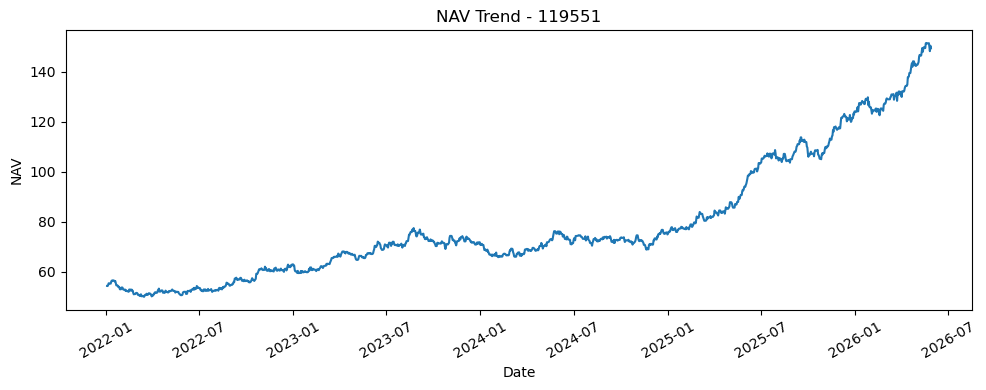

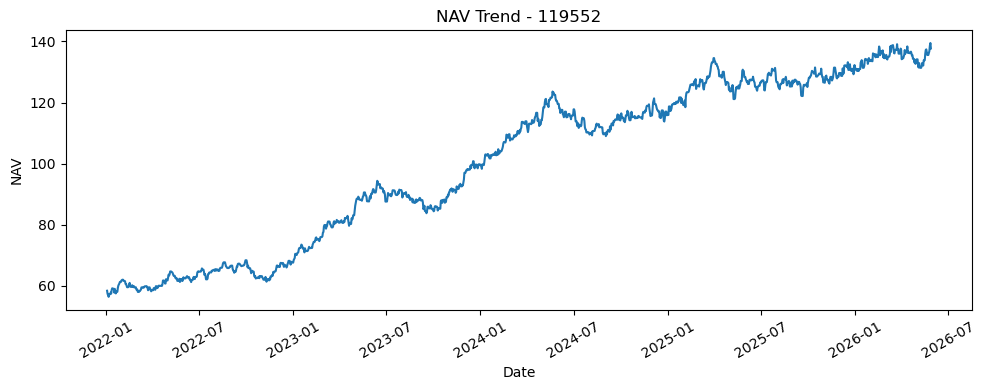

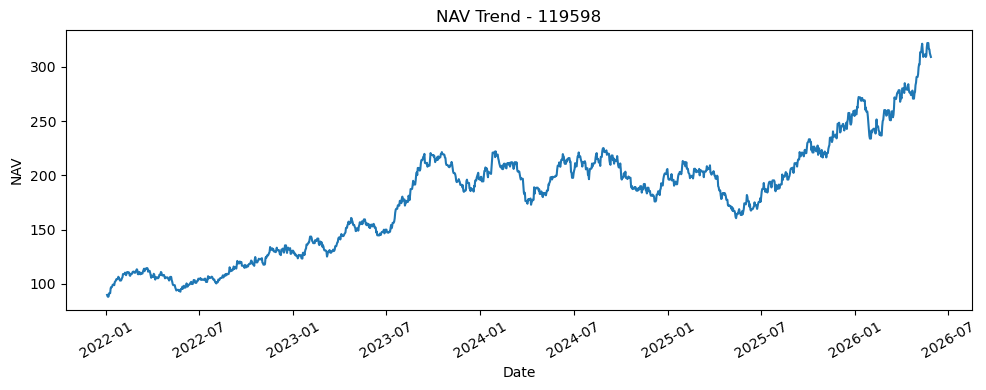

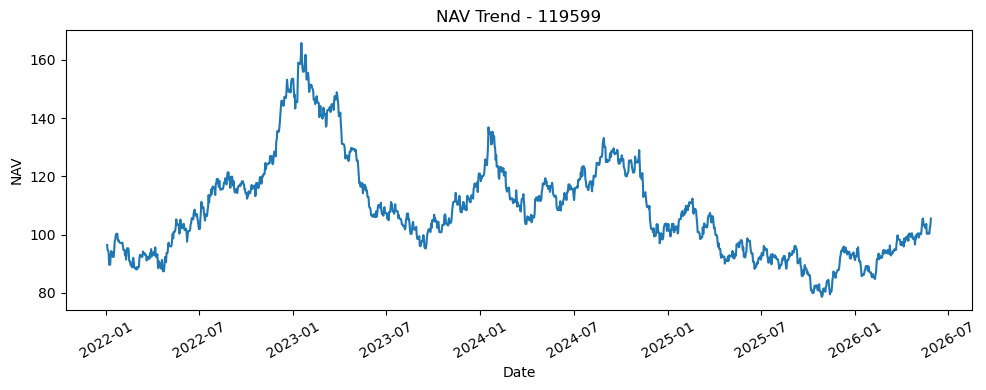

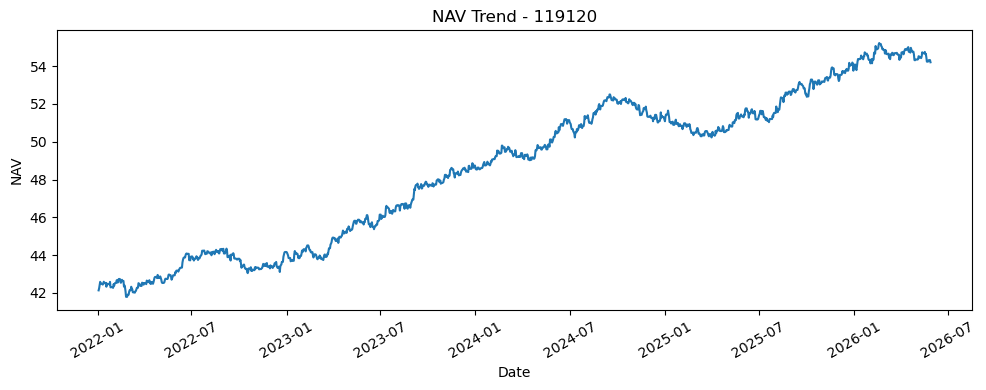

In [3]:

top_codes = funds["amfi_code"].head(5).tolist()

for code in top_codes:
    x = nav[nav["amfi_code"] == code]
    plt.figure(figsize=(10,4))
    plt.plot(x["date"], x["nav"])
    plt.title(f"NAV Trend - {code}")
    plt.xlabel("Date")
    plt.ylabel("NAV")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


## 3. Risk and Return

In [4]:

display(
    perf[
        [
            "scheme_name",
            "category",
            "return_1yr_pct",
            "return_3yr_pct",
            "return_5yr_pct",
            "sharpe_ratio",
            "max_drawdown_pct",
            "risk_grade"
        ]
    ].sort_values("return_3yr_pct", ascending=False).head(10)
)


,scheme_name,category,return_1yr_pct,return_3yr_pct,return_5yr_pct,sharpe_ratio,max_drawdown_pct,risk_grade
2,SBI Small Cap Fund - Regular Plan - Growth,Small Cap,24.56,23.39,20.67,0.94,-13.35,Very High
3,SBI Small Cap Fund - Direct Plan - Growth,Small Cap,20.59,23.14,21.82,0.93,-24.78,Very High
29,ABSL Small Cap Fund - Regular - Growth,Small Cap,24.93,22.38,23.80,0.90,-23.61,Very High
27,Axis Small Cap Fund - Regular - Growth,Small Cap,21.97,20.98,22.62,0.84,-14.45,Very High
17,Nippon India Small Cap Fund - Regular - Growth,Small Cap,21.30,20.15,21.88,0.81,-30.87,Very High
39,DSP Small Cap Fund - Regular - Growth,Small Cap,20.20,20.08,20.61,0.80,-17.01,Very High
21,Kotak Emerging Equity Fund - Regular - Growth,Mid Cap,17.12,18.23,17.75,0.96,-21.92,High
12,ICICI Pru Midcap Fund - Regular - Growth,Mid Cap,14.02,18.08,17.55,0.95,-21.84,High
38,DSP Midcap Fund - Regular - Growth,Mid Cap,14.12,17.16,19.00,0.90,-26.99,High
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Mid Cap,15.43,16.58,17.69,0.87,-13.67,High



## Key Findings

- The dataset contains 40 mutual fund schemes across multiple categories.
- NAV history provides daily observations suitable for return and risk analysis.
- Scheme performance can be compared using return, Sharpe ratio and maximum drawdown.
- Risk grades provide an additional qualitative segmentation of schemes.
